In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#1 DATA PREPROCESSING
from google.colab import files

uploaded = files.upload()

Saving ABC Company.xlsx to ABC Company (1).xlsx


In [3]:
df = pd.read_excel("ABC Company.xlsx")

df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [4]:
print(df.columns)

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')


In [6]:
np.random.seed(100)

df["Height"] = np.random.randint(150, 181, size=len(df))

df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,158,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,174,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,153,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,157,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,173,231,NaN,5000000.0


In [8]:
#2. Employee Distribution Across Teams
team_count = df["Team"].value_counts()

team_percentage = (team_count/len(df))*100

print(team_count)
print(team_percentage)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz               

In [9]:
#3. Employees Based on Position
position_count = df["Position"].value_counts()

print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


In [10]:
#4. Predominant Age Group
bins=[18,25,30,35,40,45,50]

labels=["18-25","26-30","31-35","36-40","41-45","46-50"]

df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

age_group=df["Age Group"].value_counts()

print(age_group)


Age Group
18-25    200
26-30    167
31-35     68
36-40     23
41-45      0
46-50      0
Name: count, dtype: int64


In [11]:
#5. Salary Expenditure
team_salary=df.groupby("Team")["Salary"].sum()

print(team_salary)

Team
Atlanta Hawks              72902950.0
Boston Celtics             58541068.0
Brooklyn Nets              52528475.0
Charlotte Hornets          78340920.0
Chicago Bulls              86783378.0
Cleveland Cavaliers       106988689.0
Dallas Mavericks           71198732.0
Denver Nuggets             60121930.0
Detroit Pistons            67168263.0
Golden State Warriors      88868997.0
Houston Rockets            75283021.0
Indiana Pacers             66751826.0
Los Angeles Clippers       94854640.0
Los Angeles Lakers         71770431.0
Memphis Grizzlies          76550880.0
Miami Heat                 82515673.0
Milwaukee Bucks            69603517.0
Minnesota Timberwolves     59709697.0
New Orleans Pelicans       82750774.0
New York Knicks            73303898.0
Oklahoma City Thunder      93765298.0
Orlando Magic              60161470.0
Philadelphia 76ers         30992894.0
Phoenix Suns               63445135.0
Portland Trail Blazers     48301818.0
Sacramento Kings           71683666.0
San Ant

In [12]:
#Position-wise Salary
position_salary=df.groupby("Position")["Salary"].sum()

print(position_salary)


Position
C     466377332.0
PF    442560850.0
PG    446848971.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64


In [15]:
#6. Correlation Between Age and Salary
correlation=df["Age"].corr(df["Salary"])

print('correlation',correlation)


correlation 0.21400941226570971


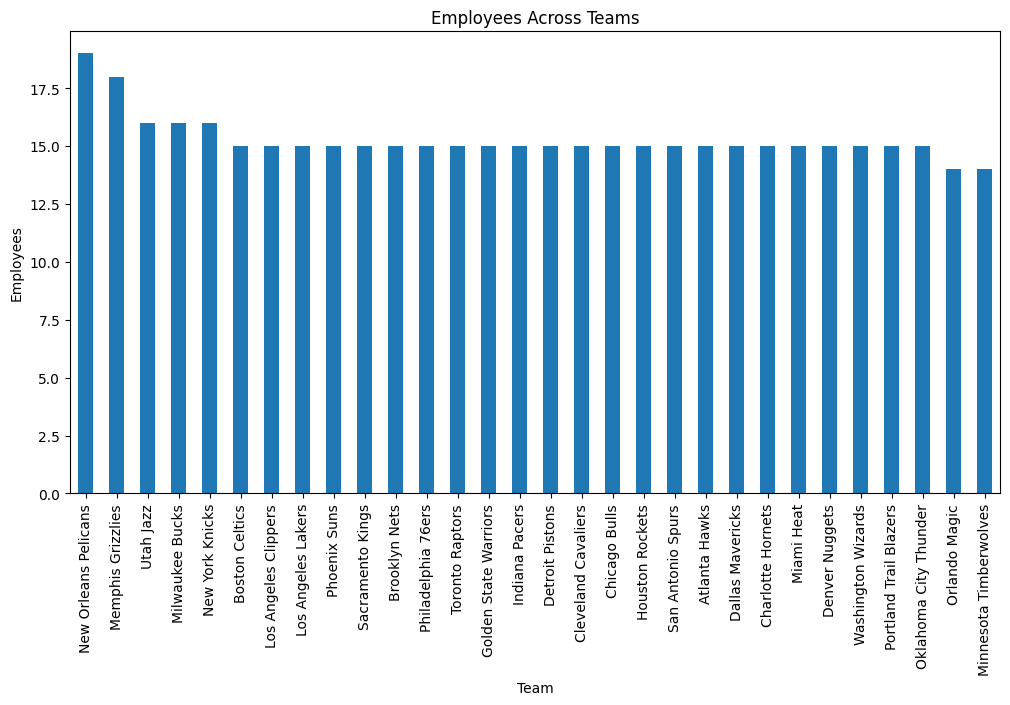

In [16]:
#Team Distribution
team_count.plot(kind="bar",figsize=(12,6))
plt.title("Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Employees")
plt.xticks(rotation=90)
plt.show()

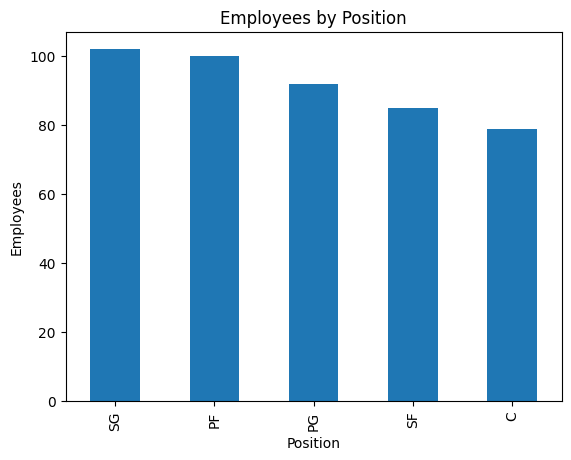

In [17]:
#Position Distribution
position_count.plot(kind="bar")
plt.title("Employees by Position")
plt.xlabel("Position")
plt.ylabel("Employees")
plt.show()

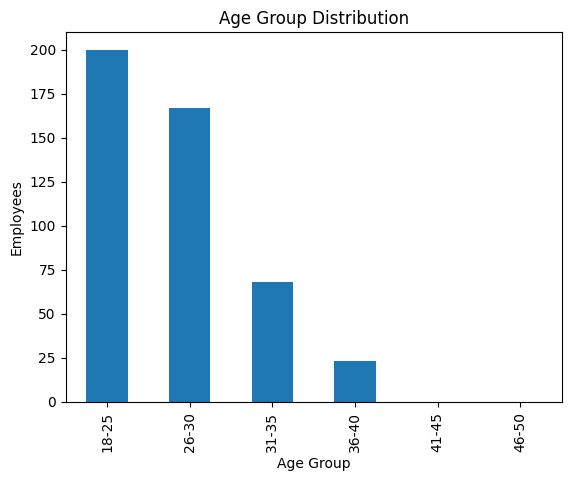

In [18]:
#Age Group
age_group.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Employees")
plt.show()

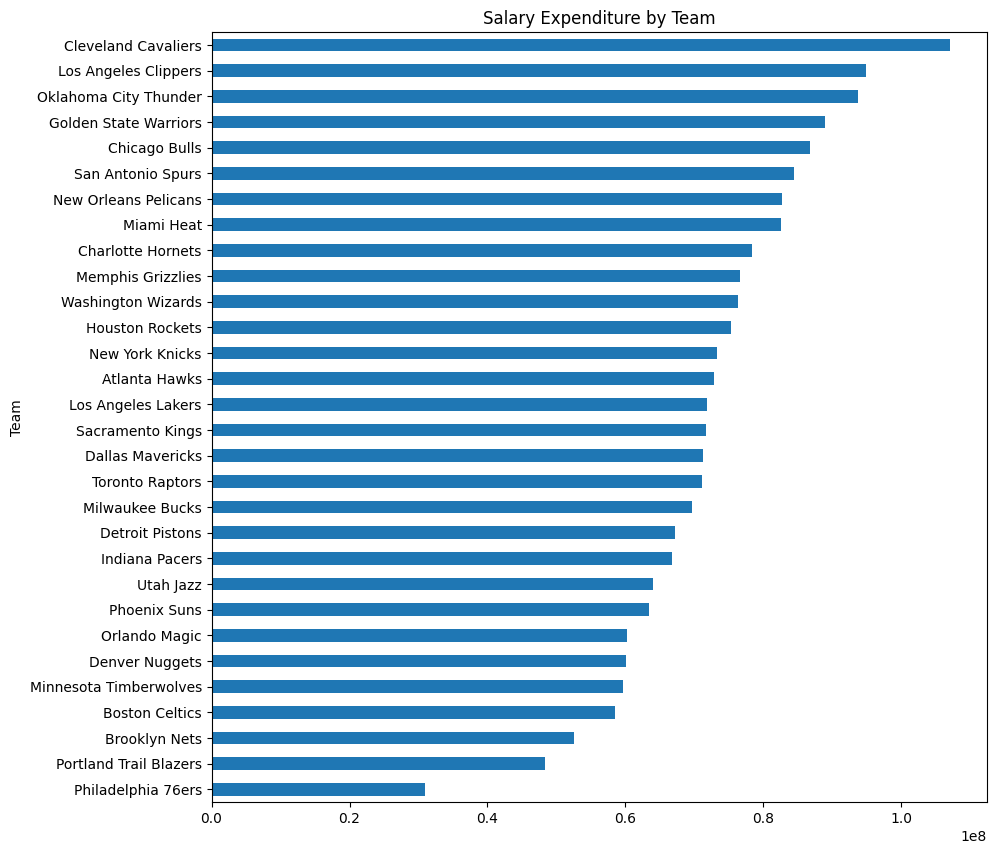

In [19]:
#Salary by Team
team_salary.sort_values().plot(kind="barh",figsize=(10,10))
plt.title("Salary Expenditure by Team")
plt.show()

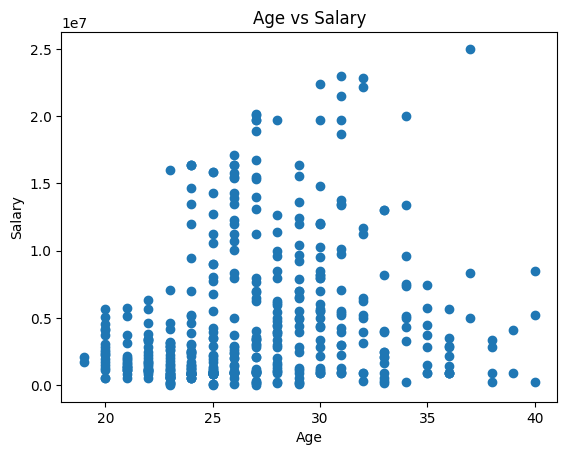

In [20]:
#Age vs Salary
plt.scatter(df["Age"],df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

# Data Story

The ABC Company employee dataset consists of **458 employees** with information such as team, position, age, height, weight, college, and salary. Before analysis, the **Height** column was preprocessed by replacing the existing values with random values between **150 cm and 180 cm** to ensure data consistency, as required by the project.

The analysis showed that employees are distributed across multiple teams, with some teams having a larger workforce than others. This helps in understanding the allocation of employees within the company.

Position-wise analysis revealed that **Shooting Guard (SG)** is the most common employee position, while **Center (C)** has the fewest employees. This indicates that certain positions require more personnel than others.

Age group analysis showed that the majority of employees fall within the **18–25 years** age group, suggesting that the company has a relatively young workforce.

Salary analysis identified the team with the highest overall salary expenditure and showed that the **Center (C)** position accounts for the highest total salary expenditure among all positions. This provides useful insight into payroll distribution across teams and job roles.

Finally, the correlation between **Age** and **Salary** was analyzed using a scatter plot and Pearson correlation coefficient. The results indicate a **weak positive correlation**, meaning that salary tends to increase slightly with age, but age alone is not a strong factor in determining employee salary.

Overall, this project demonstrates how Python, Pandas, NumPy, and Matplotlib can be used to preprocess data, perform meaningful analysis, visualize results, and extract valuable business insights from a real-world dataset.
